In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam, RMSprop

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
import os

DATASET_PATH = os.path.join(
    "archive",
    "real_vs_fake",
    "real-vs-fake"
)

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VALID_DIR = os.path.join(DATASET_PATH, "valid")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print(TRAIN_DIR)
print(VALID_DIR)
print(TEST_DIR)

print(os.path.exists(TRAIN_DIR))
print(os.path.exists(VALID_DIR))
print(os.path.exists(TEST_DIR))

archive\real_vs_fake\real-vs-fake\train
archive\real_vs_fake\real-vs-fake\valid
archive\real_vs_fake\real-vs-fake\test
True
True
True


In [4]:
FAKE_TRAIN_DIR = os.path.join(TRAIN_DIR, "fake")
REAL_TRAIN_DIR = os.path.join(TRAIN_DIR, "real")

FAKE_VALID_DIR = os.path.join(VALID_DIR, "fake")
REAL_VALID_DIR = os.path.join(VALID_DIR, "real")

FAKE_TEST_DIR = os.path.join(TEST_DIR, "fake")
REAL_TEST_DIR = os.path.join(TEST_DIR, "real")

print("Train fake:", os.path.exists(FAKE_TRAIN_DIR))
print("Train real:", os.path.exists(REAL_TRAIN_DIR))

print("Valid fake:", os.path.exists(FAKE_VALID_DIR))
print("Valid real:", os.path.exists(REAL_VALID_DIR))

print("Test fake:", os.path.exists(FAKE_TEST_DIR))
print("Test real:", os.path.exists(REAL_TEST_DIR))

Train fake: True
Train real: True
Valid fake: True
Valid real: True
Test fake: True
Test real: True


## EDA

In [5]:
df = pd.read_csv ("C:\PGS\TECH405\Deepfake Image Detection\deepfakedataset.csv")

df.head()

,Unnamed: 0,original_path,id,label,label_str,path
0,0,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,18233,1,real,test/real/18233.jpg
1,1,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,54317,1,real,test/real/54317.jpg
2,2,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,40155,1,real,test/real/40155.jpg
3,3,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,12875,1,real,test/real/12875.jpg
4,4,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,52543,1,real,test/real/52543.jpg


In [6]:
print(df.shape)

print(df.info())

df.describe()

(20000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Unnamed: 0     20000 non-null  int64
 1   original_path  20000 non-null  str  
 2   id             20000 non-null  str  
 3   label          20000 non-null  int64
 4   label_str      20000 non-null  str  
 5   path           20000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 937.6 KB
None


,Unnamed: 0,label
count,20000.000000,20000.000000
mean,4999.500000,0.500000
std,2886.823503,0.500013
min,0.000000,0.000000
25%,2499.750000,0.000000
50%,4999.500000,0.500000
75%,7499.250000,1.000000
max,9999.000000,1.000000


In [7]:
df.isnull().sum()

Unnamed: 0       0
original_path    0
id               0
label            0
label_str        0
path             0
dtype: int64

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


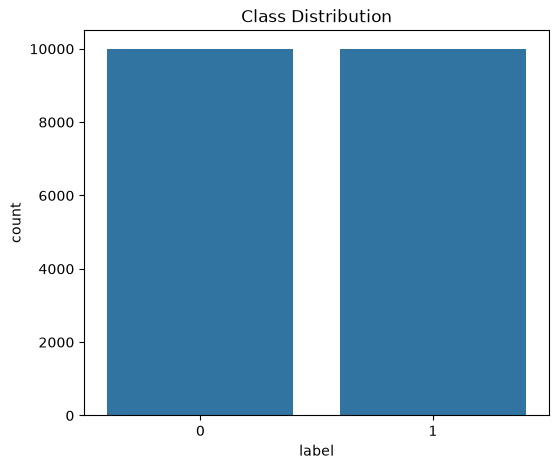

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(x=df["label"])

plt.title("Class Distribution")

plt.show()

## Data Augmentation

In [10]:
IMG_SIZE = (128,128)

BATCH_SIZE = 32

In [11]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True

)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

## Data generators

In [12]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True

)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [13]:
train_generator = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary'

)

Found 100000 images belonging to 2 classes.


In [14]:
valid_generator = validation_datagen.flow_from_directory(

    VALID_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary'

)

Found 20000 images belonging to 2 classes.


In [15]:
test_generator = test_datagen.flow_from_directory(

    TEST_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False,

    class_mode='binary'

)

Found 20000 images belonging to 2 classes.


In [16]:
print("Training Images:", train_generator.samples)

print("Validation Images:", valid_generator.samples)

print("Testing Images:", test_generator.samples)

Training Images: 100000
Validation Images: 20000
Testing Images: 20000


### Sample Visualization

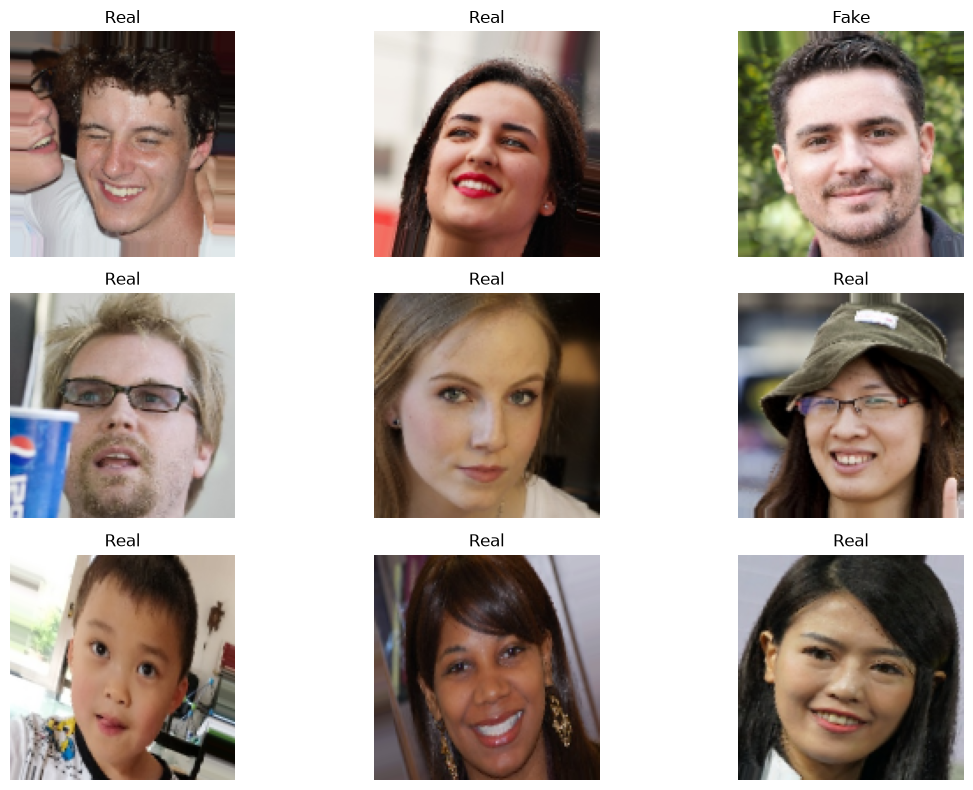

In [17]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title("Real" if labels[i]==1 else "Fake")

    plt.axis("off")

plt.tight_layout()

plt.show()

## Building CNN model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

### Compile

In [19]:
cnn_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

### Train CNN

In [20]:

EPOCHS = 10

history = cnn_model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=EPOCHS





)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3341s 1s/step - accuracy: 0.6451 - loss: 0.6410 - val_accuracy: 0.7199 - val_loss: 0.5686
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1742s 558ms/step - accuracy: 0.7314 - loss: 0.5370 - val_accuracy: 0.7985 - val_loss: 0.4337
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1455s 466ms/step - accuracy: 0.7759 - loss: 0.4777 - val_accuracy: 0.7556 - val_loss: 0.5049
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1359s 435ms/step - accuracy: 0.8030 - loss: 0.4339 - val_accuracy: 0.8241 - val_loss: 0.4000
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1193s 382ms/step - accuracy: 0.8279 - loss: 0.3953 - val_accuracy: 0.7976 - val_loss: 0.6370
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1178s 377ms/step - accuracy: 0.8448 - loss: 0.3653 - val_accuracy: 0.8789 - val_loss: 0.2871
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1167s 373ms/step - accuracy: 0.8592 - loss: 0.3381 - val_accuracy: 0.8577 - val_loss: 0.3600
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1126s 360ms/step

## PLOTS

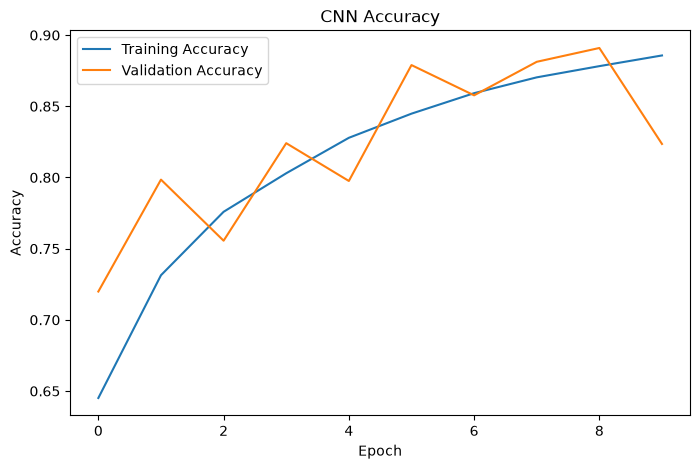

In [21]:
## ACCURACY

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

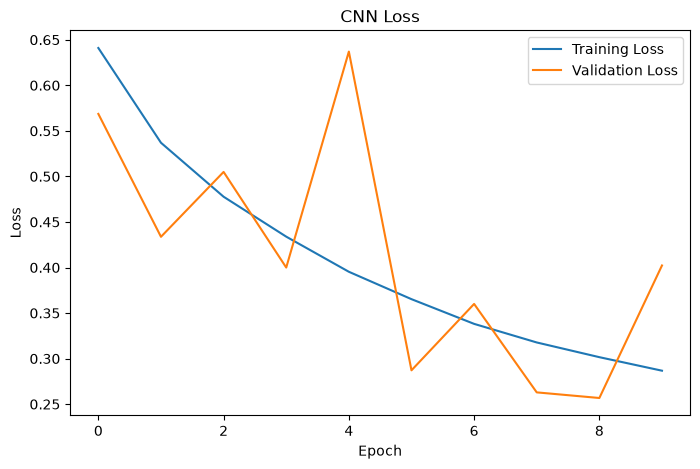

In [22]:
## LOSS

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Evaluate on Test Set

In [23]:

test_loss, test_accuracy = cnn_model.evaluate(test_generator)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.8230 - loss: 0.4109
Test Loss : 0.4108676314353943
Test Accuracy : 0.822950005531311


In [24]:
## PREDICTION

test_generator.reset()

predictions = cnn_model.predict(test_generator)

y_pred = (predictions > 0.5).astype(int).flatten()

y_true = test_generator.classes

625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step


In [25]:
## PRECISION, RECALL, F1

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Precision : 0.9712534656354881
Recall : 0.6656
F1 Score : 0.7898890405269091


In [26]:
## ROC - AUC SCORE

auc_score = roc_auc_score(y_true, predictions)

print("ROC-AUC :", auc_score)

ROC-AUC : 0.9648515450000001


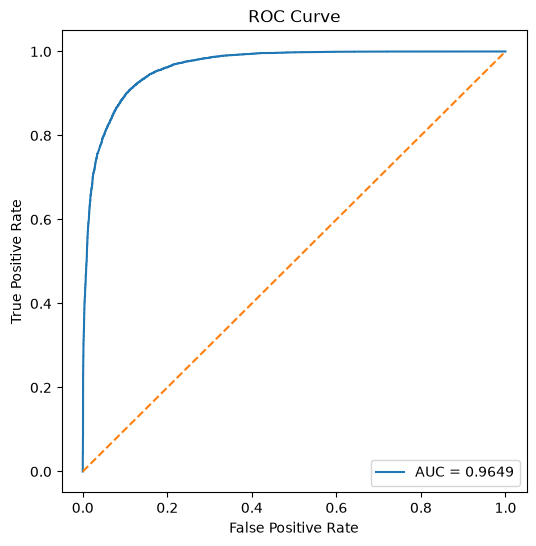

In [27]:
## ROC CURVE

fpr, tpr, thresholds = roc_curve(y_true, predictions)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr,
         label="AUC = %.4f" % auc_score)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

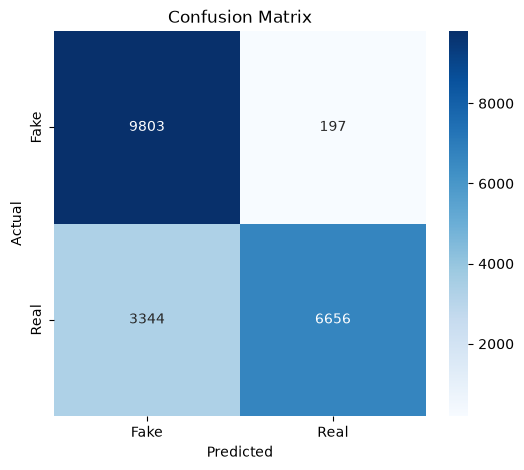

In [28]:
## CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=['Fake','Real'],

    yticklabels=['Fake','Real']

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [29]:
## CLASSIFICATION REPORT

print(classification_report(

    y_true,

    y_pred,

    target_names=['Fake','Real']

))

              precision    recall  f1-score   support

        Fake       0.75      0.98      0.85     10000
        Real       0.97      0.67      0.79     10000

    accuracy                           0.82     20000
   macro avg       0.86      0.82      0.82     20000
weighted avg       0.86      0.82      0.82     20000



## Hyperparamter Experiments

In [20]:
BATCH_SIZE = 64

In [21]:
train_generator_64 = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=(128,128),

    batch_size=BATCH_SIZE,

    class_mode='binary'

)

valid_generator_64 = validation_datagen.flow_from_directory(

    VALID_DIR,

    target_size=(128,128),

    batch_size=BATCH_SIZE,

    class_mode='binary'

)

test_generator_64 = test_datagen.flow_from_directory(

    TEST_DIR,

    target_size=(128,128),

    batch_size=BATCH_SIZE,

    class_mode='binary',

    shuffle=False

)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [22]:
cnn_model_64 = tf.keras.models.clone_model(cnn_model)

cnn_model_64.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [34]:
history_64 = cnn_model_64.fit(

    train_generator_64,

    validation_data=valid_generator_64,

    epochs=10

)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1084s 694ms/step - accuracy: 0.8616 - loss: 0.3317 - val_accuracy: 0.8720 - val_loss: 0.2993
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1140s 729ms/step - accuracy: 0.8775 - loss: 0.3018 - val_accuracy: 0.8924 - val_loss: 0.2622
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1041s 666ms/step - accuracy: 0.8902 - loss: 0.2746 - val_accuracy: 0.9160 - val_loss: 0.2110
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1045s 669ms/step - accuracy: 0.9011 - loss: 0.2514 - val_accuracy: 0.9161 - val_loss: 0.2148
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1046s 669ms/step - accuracy: 0.9078 - loss: 0.2329 - val_accuracy: 0.9301 - val_loss: 0.1732
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1040s 666ms/step - accuracy: 0.9141 - loss: 0.2201 - val_accuracy: 0.9209 - val_loss: 0.1969
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1261s 807ms/step - accuracy: 0.9194 - loss: 0.2095 - val_accuracy: 0.9121 - val_loss: 0.2472
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1351s 865ms/s

In [35]:
loss64, accuracy64 = cnn_model_64.evaluate(test_generator_64)

print("Accuracy (Batch Size = 64):", accuracy64)

313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 200ms/step - accuracy: 0.9259 - loss: 0.1969
Accuracy (Batch Size = 64): 0.9259499907493591


In [36]:
comparison = pd.DataFrame({

    "Experiment":[

        "Batch Size = 32",

        "Batch Size = 64"

    ],

    "Accuracy":[

        test_accuracy,

        accuracy64

    ]

})

comparison

,Experiment,Accuracy
0,Batch Size = 32,0.82295
1,Batch Size = 64,0.92595


## MobileNetV2 (Transfer Learning)

In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

### Load Pre-trained Model

In [24]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze pretrained layers
base_model.trainable = False

### Building Model

In [26]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

mobilenet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compile

In [27]:
mobilenet_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

### Train

In [28]:
history_mobile = mobilenet_model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=10

)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1830s 584ms/step - accuracy: 0.7028 - loss: 0.5736 - val_accuracy: 0.7466 - val_loss: 0.5221
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 691s 221ms/step - accuracy: 0.7279 - loss: 0.5401 - val_accuracy: 0.7559 - val_loss: 0.5020
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 612s 196ms/step - accuracy: 0.7364 - loss: 0.5313 - val_accuracy: 0.7600 - val_loss: 0.4928
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 607s 194ms/step - accuracy: 0.7440 - loss: 0.5193 - val_accuracy: 0.7595 - val_loss: 0.4964
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 608s 195ms/step - accuracy: 0.7497 - loss: 0.5123 - val_accuracy: 0.7679 - val_loss: 0.4824
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 609s 195ms/step - accuracy: 0.7515 - loss: 0.5058 - val_accuracy: 0.7639 - val_loss: 0.4866
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 612s 196ms/step - accuracy: 0.7532 - loss: 0.5061 - val_accuracy: 0.7702 - val_loss: 0.4779
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 614s 197ms/step - a

## PLOTS

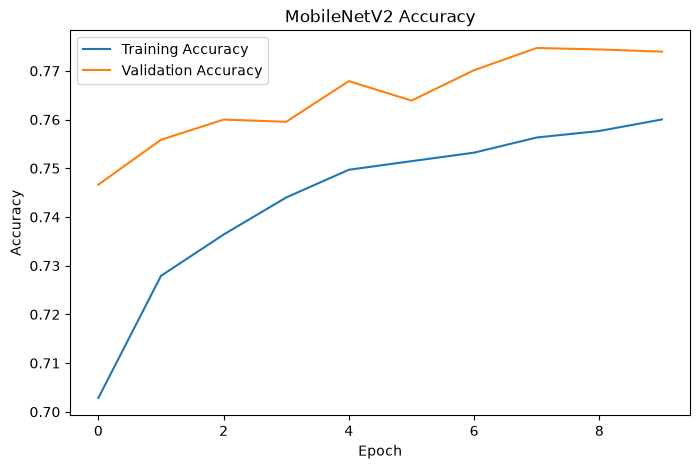

In [29]:
## ACCURACY

plt.figure(figsize=(8,5))

plt.plot(history_mobile.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_mobile.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("MobileNetV2 Accuracy")

plt.legend()

plt.show()

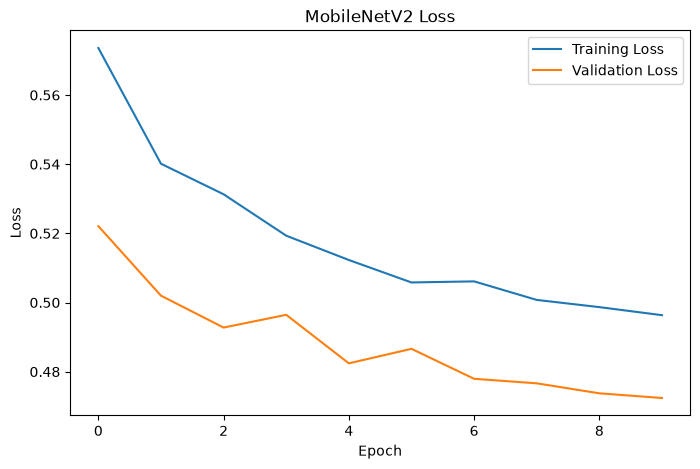

In [30]:
## LOSS

plt.figure(figsize=(8,5))

plt.plot(history_mobile.history['loss'],
         label='Training Loss')

plt.plot(history_mobile.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("MobileNetV2 Loss")

plt.legend()

plt.show()

In [31]:
## EVALUATE MODEL

mobile_loss, mobile_accuracy = mobilenet_model.evaluate(test_generator)

print("Test Loss :", mobile_loss)

print("Test Accuracy :", mobile_accuracy)

625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 164ms/step - accuracy: 0.7767 - loss: 0.4746
Test Loss : 0.4746445417404175
Test Accuracy : 0.7766500115394592


In [32]:
## PREDICTIONS

test_generator.reset()

mobile_predictions = mobilenet_model.predict(test_generator)

mobile_pred = (mobile_predictions > 0.5).astype(int).flatten()

y_true = test_generator.classes

625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 154ms/step


In [33]:
## PRECISION, RECALL, F1

mobile_precision = precision_score(y_true, mobile_pred)

mobile_recall = recall_score(y_true, mobile_pred)

mobile_f1 = f1_score(y_true, mobile_pred)

print("Precision :", mobile_precision)

print("Recall :", mobile_recall)

print("F1 Score :", mobile_f1)

Precision : 0.8175140594513944
Recall : 0.7123
F1 Score : 0.7612889435152034


In [34]:
## ROC - AUC

mobile_auc = roc_auc_score(
    y_true,
    mobile_predictions
)

print("ROC-AUC :", mobile_auc)

ROC-AUC : 0.8618615550000001


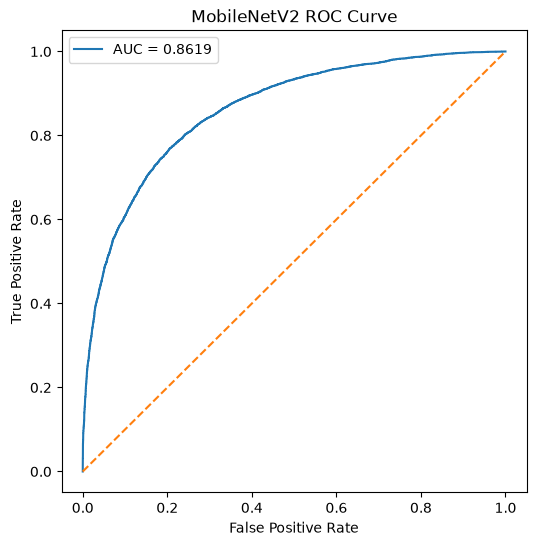

In [35]:
## ROC CURVE

fpr, tpr, threshold = roc_curve(
    y_true,
    mobile_predictions
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.4f" % mobile_auc
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("MobileNetV2 ROC Curve")

plt.legend()

plt.show()

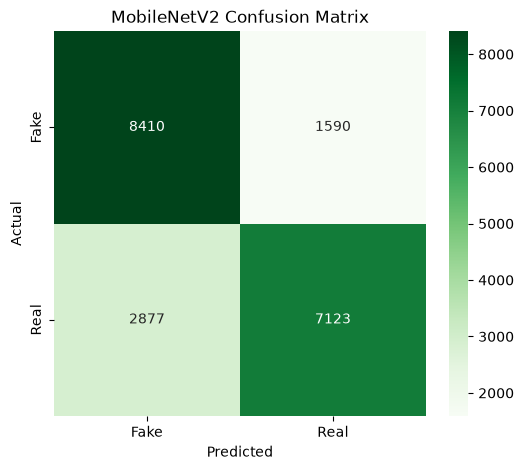

In [36]:
## CONFUSION MATRIX

cm = confusion_matrix(
    y_true,
    mobile_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Greens',

    xticklabels=['Fake','Real'],

    yticklabels=['Fake','Real']

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("MobileNetV2 Confusion Matrix")

plt.show()

In [37]:
## CLASSIFICATION REPORT

print(classification_report(

    y_true,

    mobile_pred,

    target_names=['Fake','Real']

))

              precision    recall  f1-score   support

        Fake       0.75      0.84      0.79     10000
        Real       0.82      0.71      0.76     10000

    accuracy                           0.78     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.78      0.78      0.78     20000



## ResNet50 (Transfer Learning)

In [38]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

### Load Pre-trained Model

In [39]:
base_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze pretrained layers
base_resnet.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


### Build Model

In [40]:
x = base_resnet.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

resnet_model = Model(
    inputs=base_resnet.input,
    outputs=output
)

resnet_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Compile

In [41]:
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Train

In [42]:
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1202s 383ms/step - accuracy: 0.5399 - loss: 0.6881 - val_accuracy: 0.5897 - val_loss: 0.6713
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1180s 378ms/step - accuracy: 0.5751 - loss: 0.6758 - val_accuracy: 0.6121 - val_loss: 0.6582
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1173s 375ms/step - accuracy: 0.5874 - loss: 0.6710 - val_accuracy: 0.6216 - val_loss: 0.6566
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1177s 377ms/step - accuracy: 0.5920 - loss: 0.6672 - val_accuracy: 0.6289 - val_loss: 0.6483
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1162s 372ms/step - accuracy: 0.5964 - loss: 0.6650 - val_accuracy: 0.6259 - val_loss: 0.6462
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1156s 370ms/step - accuracy: 0.5961 - loss: 0.6647 - val_accuracy: 0.6349 - val_loss: 0.6422
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1155s 370ms/step - accuracy: 0.6024 - loss: 0.6620 - val_accuracy: 0.6347 - val_loss: 0.6467
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1156s 370ms/s

## Plots

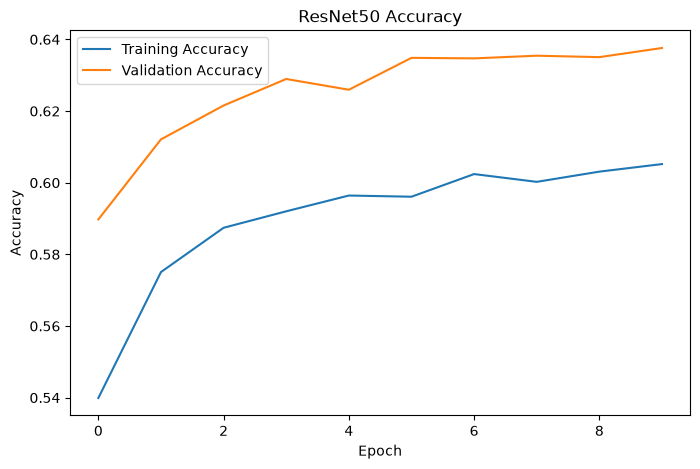

In [43]:
## ACCURACY

plt.figure(figsize=(8,5))

plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')

plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

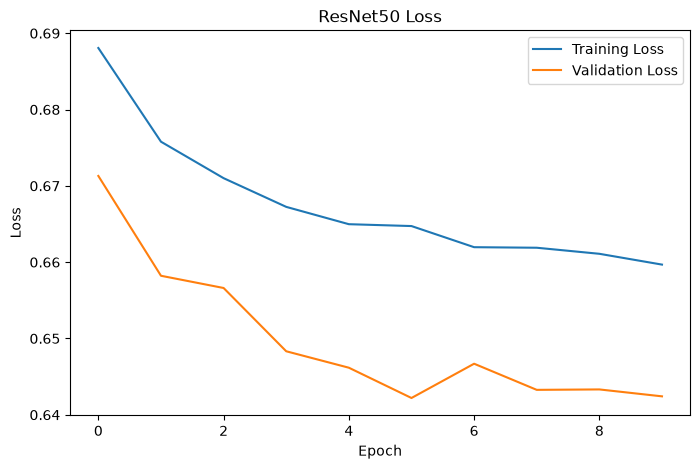

In [44]:

## LOSS

plt.figure(figsize=(8,5))

plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')

plt.title("ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [45]:
## EVALUATE

resnet_loss, resnet_accuracy = resnet_model.evaluate(test_generator)

print("Test Loss :", resnet_loss)
print("Test Accuracy :", resnet_accuracy)

625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 331ms/step - accuracy: 0.6402 - loss: 0.6405
Test Loss : 0.64054274559021
Test Accuracy : 0.6402000188827515


In [46]:
## PREDICTION

test_generator.reset()

resnet_predictions = resnet_model.predict(test_generator)

resnet_pred = (resnet_predictions > 0.5).astype(int).flatten()

y_true = test_generator.classes

625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 330ms/step


In [47]:
## PRECISION, RECALL, F1

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

resnet_precision = precision_score(y_true, resnet_pred)

resnet_recall = recall_score(y_true, resnet_pred)

resnet_f1 = f1_score(y_true, resnet_pred)

print("Precision :", resnet_precision)
print("Recall :", resnet_recall)
print("F1 Score :", resnet_f1)

Precision : 0.6419315650941486
Recall : 0.6341
F1 Score : 0.6379917496730053


In [48]:
## ROC - AUC SCORE

from sklearn.metrics import roc_auc_score

resnet_auc = roc_auc_score(
    y_true,
    resnet_predictions
)

print("ROC-AUC :", resnet_auc)

ROC-AUC : 0.6950331699999999


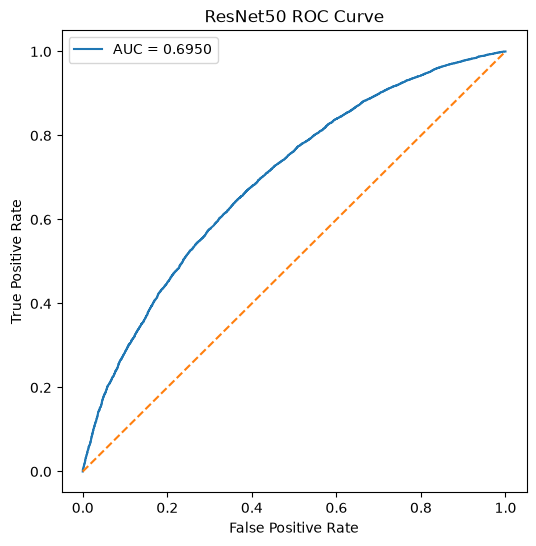

In [49]:
## RCO CURVE

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_true,
    resnet_predictions
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label='AUC = %.4f' % resnet_auc
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ResNet50 ROC Curve")

plt.legend()

plt.show()

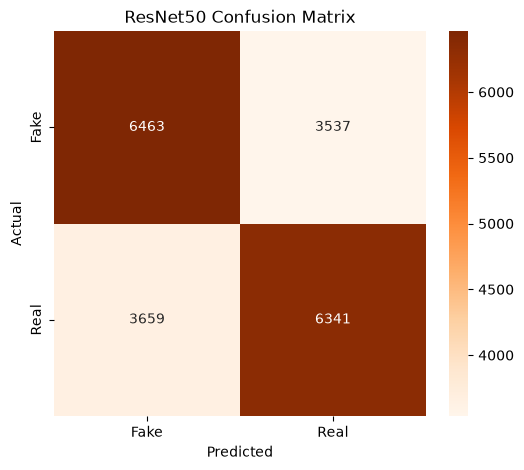

In [50]:
## CONFUSION MATRIX

cm = confusion_matrix(y_true, resnet_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Fake','Real'],
    yticklabels=['Fake','Real']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("ResNet50 Confusion Matrix")

plt.show()

In [51]:
## CLASSIFICATION REPORT

print(classification_report(
    y_true,
    resnet_pred,
    target_names=['Fake','Real']
))

              precision    recall  f1-score   support

        Fake       0.64      0.65      0.64     10000
        Real       0.64      0.63      0.64     10000

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



## FINAL COMPARISION

In [56]:

import pandas as pd

comparison = pd.DataFrame({

    "Model": [
        "CNN",
        "MobileNetV2",
        "ResNet50"
    ],

    "Accuracy": [
        0.822950005531311,
        0.7766500115394592,
        0.6402000188827515
    ],

    "Precision": [
        0.9712534656354881,
        0.8175140594513944,
        0.6419315650941486
    ],

    "Recall": [
        0.6656,
        0.7123,
        0.6341
    ],

    "F1 Score": [
        0.7898890405269091,
        0.7612889435152034,
        0.6379917496730053
    ],

    "ROC-AUC": [
        0.9648515450000001,
        0.8618615550000001,
        0.6950331699999999
    ]
})

# Round the values
comparison = comparison.round(4)

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,CNN,0.8230,0.9713,0.6656,0.7899,0.9649
1,MobileNetV2,0.7767,0.8175,0.7123,0.7613,0.8619
2,ResNet50,0.6402,0.6419,0.6341,0.6380,0.6950


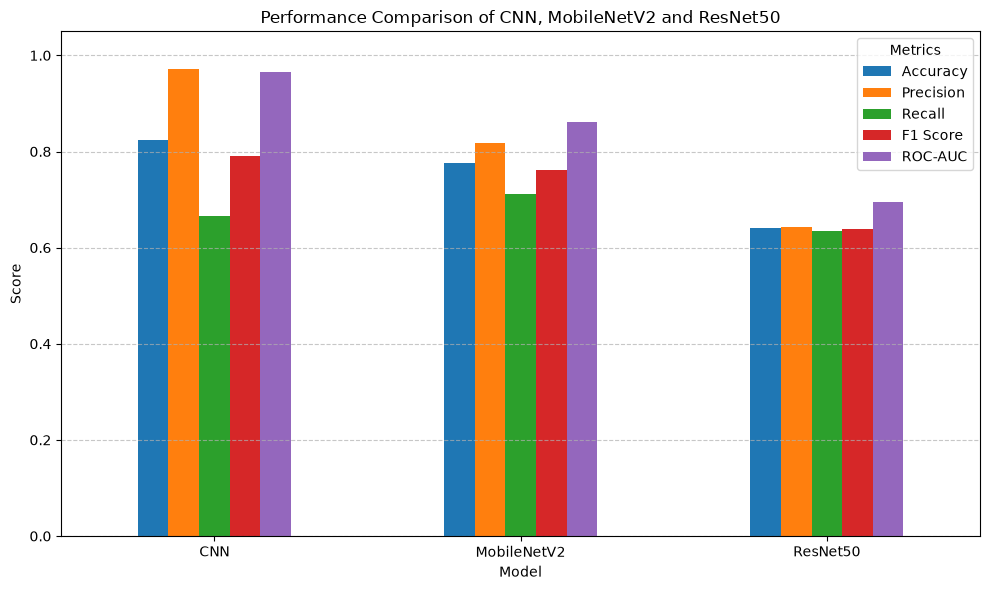

In [57]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of CNN, MobileNetV2 and ResNet50")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()